# Too Hard / Soft 분석

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
data1 = pd.read_csv("review-vc_sales_by_collection.csv")
data2 = pd.read_csv("review-vc_sales_exclude_too_hard_too_soft.csv")

In [19]:
data1

,yr_month,financial_category,collection,written_avg_rating,written_12_cnt,witten_all_cnt,written_12_ratio,all_avg_rating,all_12_cnt,all_all_cnt,all_12_ratio,sales_amount,sales_qty
0,202201,Box Springs,__TOTAL__,4.115207,77.0,434.0,0.177419,NaN,NaN,NaN,NaN,6916730.26,50316.0
1,202201,Box Springs,Walter 9in,3.500000,3.0,8.0,0.375000,NaN,NaN,NaN,NaN,91988.82,446.0
2,202201,Box Springs,Walter 7.5in,4.500000,1.0,10.0,0.100000,NaN,NaN,NaN,NaN,271300.75,1670.0
3,202201,Box Springs,Walter 4in,4.666667,1.0,9.0,0.111111,NaN,NaN,NaN,NaN,229874.12,1231.0
4,202201,Box Springs,Victor 9in,5.000000,0.0,2.0,0.000000,NaN,NaN,NaN,NaN,60917.50,297.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23388,202503,Toppers,1.5in GTFT w WonderBox,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,4739.44,117.0
23389,202503,Toppers,1.5in GT MF,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,2635.14,73.0
23390,202503,Toppers,1.5in Copper Convoluted,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN
23391,202503,Toppers,1.25in Swirl Copper,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,67.94,1.0


### Data 차이 분석

In [9]:
avg_rating1 = data1.groupby('collection')['written_avg_rating'].mean().rename('avg_rating_before')
total_sales = data1.groupby('collection')['sales_amount'].sum().rename('total_sales')
avg_rating2 = data2.groupby('collection')['written_avg_rating'].mean().rename('avg_rating_after')
avg_diff_df = pd.concat([avg_rating1, avg_rating2, total_sales], axis=1)

In [11]:
avg_diff_df

,avg_rating_before,avg_rating_after,total_sales
collection,,,
0.75in Rejuvenator,5.000000,5.000000,9.623260e+03
1.25in Swirl Copper,2.696970,2.696970,4.842095e+04
1.5in Copper Convoluted,5.000000,5.000000,0.000000e+00
1.5in GT MF,3.321465,3.345397,1.007143e+06
1.5in GTFT w WonderBox,3.250000,3.666667,6.424068e+04
...,...,...,...
Wood Squre Dining Table,NaN,NaN,0.000000e+00
Yelena 14in,3.706007,3.731648,7.816586e+06
Yelena 18in,4.435714,4.435714,7.705444e+05


In [13]:
avg_diff_df['rating_diff']=(avg_diff_df['avg_rating_before'] - avg_diff_df['avg_rating_after']).abs()

In [15]:
avg_diff_sorted = avg_diff_df.sort_values(by='total_sales', ascending=False)

In [17]:
avg_diff_sorted.to_csv('avg_diff_sorted_out1.csv')

### Too Hard/Soft 개선 효과 분석

In [22]:
cols = ['8in Ultima Foam','8in Green Tea MF','6in Ultima Foam']

In [45]:
original_cols = data1[data1['collection'].isin(cols)].copy()
excluded_cols = data2[data2['collection'].isin(cols)].copy()

In [51]:
original_cols['rating_bin'] = original_cols['written_avg_rating'].round(1)
excluded_cols['rating_bin'] = excluded_cols['written_avg_rating'].round(1)

In [80]:
original_cols['sales_amount'].sum()
#excluded_cols['sales_amount'].sum()

48160754.61000001

In [ ]:
#platform_cols['rating_bin'] = platform_cols['written_avg_rating'].round(1)

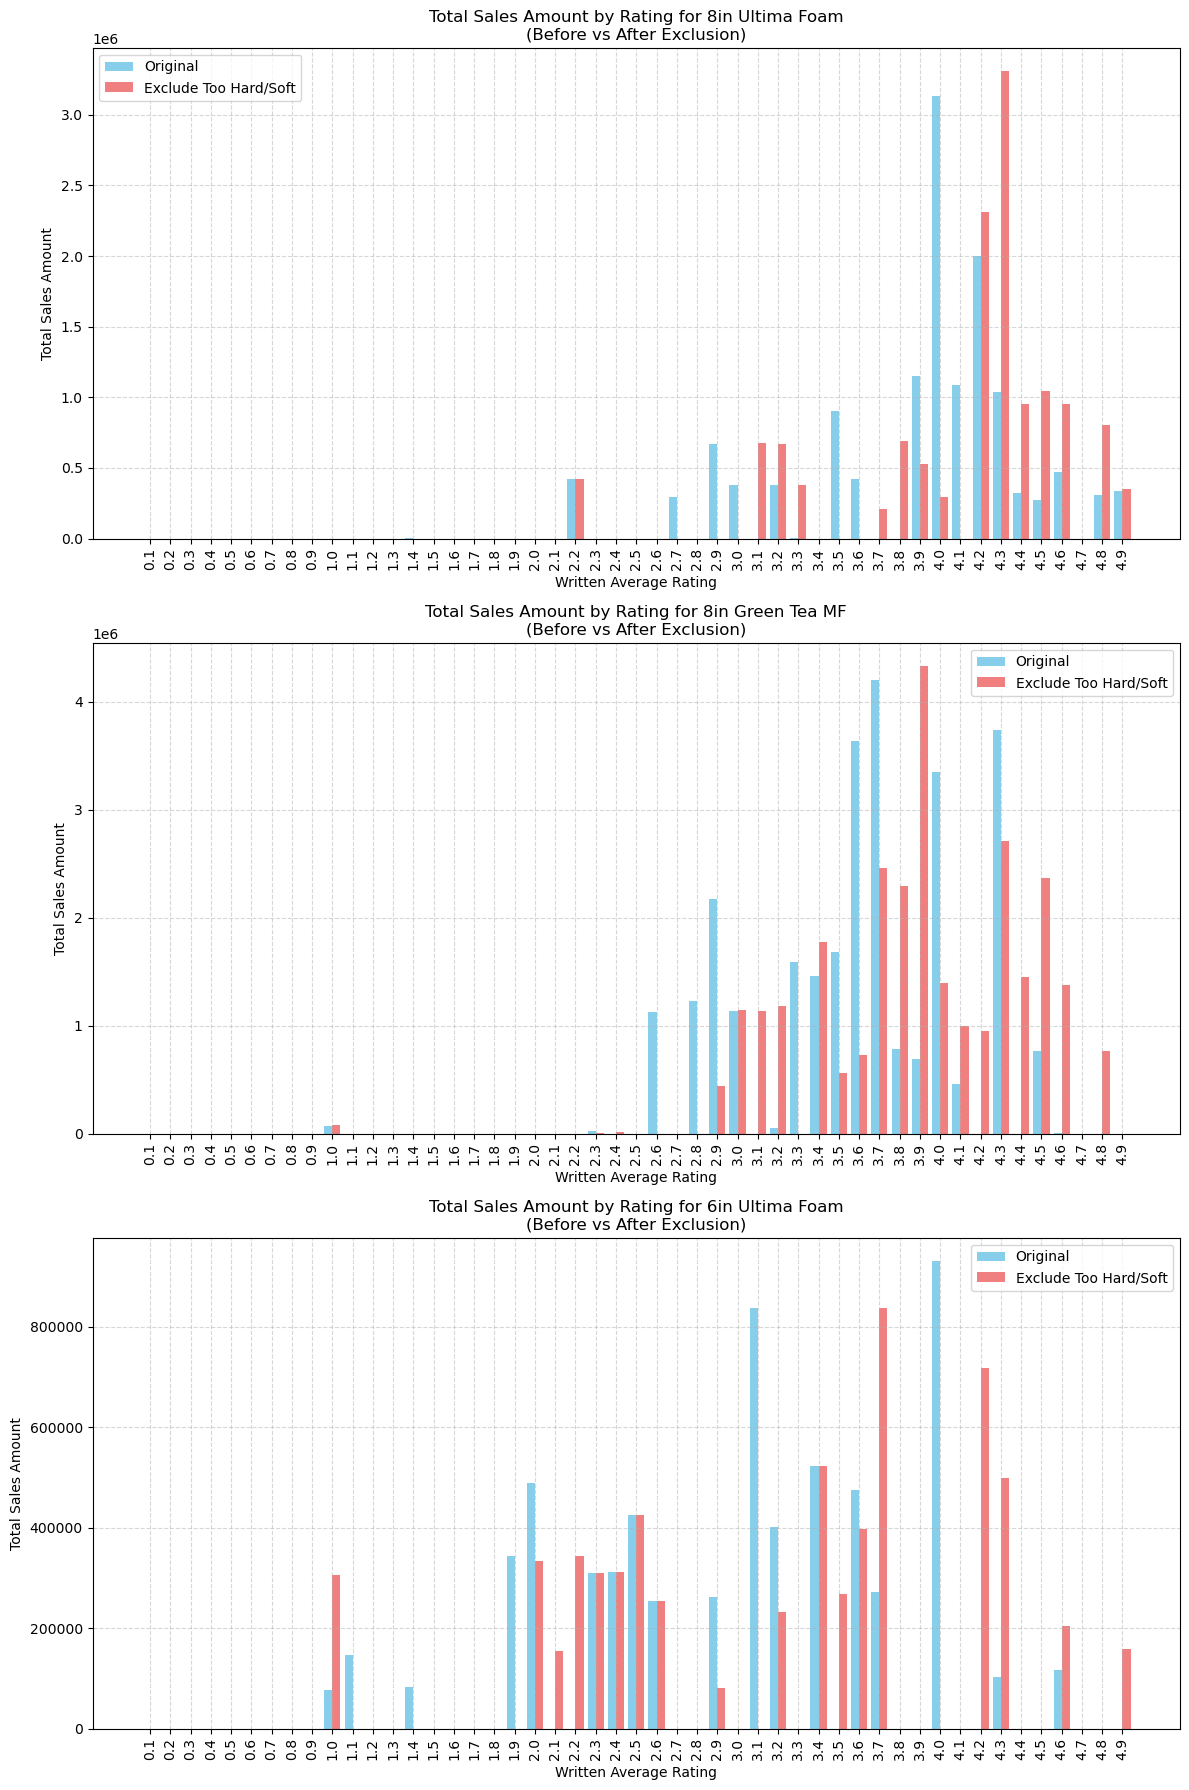

In [76]:
fig, axes = plt.subplots(3,1,figsize=(12,18))
bins = np.arange(0.1,5.1,0.1)

for i, collection in enumerate(cols):
    original_cols_data = original_cols[original_cols['collection']==collection] 
    excluded_cols_data = excluded_cols[excluded_cols['collection']==collection]

    original_hist, _ = np.histogram(original_cols_data['written_avg_rating'], bins=bins, weights=original_cols_data['sales_amount'])
    excluded_hist, _ = np.histogram(excluded_cols_data['written_avg_rating'], bins=bins, weights=excluded_cols_data['sales_amount'])

    bar_width = 0.4
    indices = np.arange(len(bins)-1)

    axes[i].bar(indices, original_hist, bar_width, label='Original', color='skyblue')
    axes[i].bar(indices+bar_width, excluded_hist, bar_width, label='Exclude Too Hard/Soft', color='lightcoral')

    axes[i].set_xlabel('Written Average Rating')
    axes[i].set_ylabel('Total Sales Amount')
    axes[i].set_title(f'Total Sales Amount by Rating for {collection}\n(Before vs After Exclusion)')

    axes[i].set_xticks(indices+bar_width/2)
    axes[i].set_xticklabels([f'{bins[j]:.1f}' for j in range(len(bins)-1)], rotation=90)
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()